## Data-driven EIT Reconstruction — Ridge Regression

Since I am not a physics and I do not have a deeply understanding of the various process of the algorithms to solve forward and backward problem. I decided to approach the problem with something I am more familiar with. It's possible to learn the trasformation from 208 measurement to recostructed 32x32 pixel map?
Is it a linear transformation?

Learns the Dräger PulmoVista 500 reconstruction mapping directly from
paired `.eit` / `.bin` recordings.

- **v1**: input = `vv` (208 calibrated transimpedances from Adler formula)
- **v1b**: input = `[trans_A, trans_B]` (416 raw ADC features — bypasses calibration constants)

### Dataset
- **patient01**: 9 recordings (rec02–rec13, different NIV interfaces, same patient)
- **patient02**: 1 recording

### Train/test protocol
- per-recording baseline normalisation (subtract mean of first 50 frames)
- 80/20 sequential split per recording, then concatenate
- StandardScaler fitted on training data only

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler

from fasteit.reconstruction.data_prep import load_paired, normalize
from fasteit.reconstruction.metrics import (
    correlation_per_frame,
    error_map,
    mse_per_frame,
    summary_metrics,
)
from fasteit.reconstruction.ridge_model import RidgeReconstructor

# Custom EIT colormap inspired by Dräger PulmoVista 500 display.
# violet (neg ΔZ) → black (zero) → blue → white (pos ΔZ, ventilation)
# NOTE: not the exact Dräger palette — a simplified approximation.
CMAP_EIT = LinearSegmentedColormap.from_list("draeger", [
    (0.00, (0.5, 0.0, 0.5)),   # violet — negative ΔZ
    (0.50, (0.0, 0.0, 0.0)),   # black  — zero (baseline)
    (0.80, (0.0, 0.0, 1.0)),   # blue   — positive ΔZ
    (1.00, (1.0, 1.0, 1.0)),   # white  — max ventilation
])

## 1. Load paired data (9 patient01 recordings + patient02)

In [2]:
# Robust data root resolution (works whether cwd is repo root or notebooks/)
_DATA_CANDIDATES = [Path('src/fasteit/test_files'), Path('../src/fasteit/test_files')]
for _cand in _DATA_CANDIDATES:
    if (_cand / 'patient02.eit').exists():
        DATA = _cand
        break
else:
    raise FileNotFoundError('Could not locate test files.')


# All recordings: (label, patient_id, eit_path, bin_path)
RECORDINGS = []
for rec in ['rec02', 'rec03', 'rec04', 'rec05', 'rec07', 'rec09',
            'rec11', 'rec12', 'rec13']:
    eit = DATA / f'patient01_{rec}.eit'
    bin_ = DATA / f'patient01_{rec}.bin'
    if eit.exists() and bin_.exists():
        RECORDINGS.append((f'p01_{rec}', 'patient01', eit, bin_))

RECORDINGS.append(('patient02', 'patient02', DATA / 'patient02.eit', DATA / 'patient02.bin'))

# Load each recording, extract both feature sets
X_vv_by_rec = []
X_raw416_by_rec = []
Y_by_rec = []
rec_labels = []
patient_ids = []

for label, pid, eit_f, bin_f in RECORDINGS:
    X_vv, Y = load_paired(eit_f, bin_f, input_mode='vv')
    X_416, _ = load_paired(eit_f, bin_f, input_mode='raw')

    X_vv_by_rec.append(X_vv)
    X_raw416_by_rec.append(X_416)
    Y_by_rec.append(Y)
    rec_labels.append(label)
    patient_ids.append(pid)
    print(f'{label}: vv={X_vv.shape}, raw416={X_416.shape}, Y={Y.shape}')

print(f'\nTotal recordings: {len(RECORDINGS)}')

p01_rec02: vv=(1600, 208), raw416=(1600, 416), Y=(1600, 1024)
p01_rec03: vv=(5750, 208), raw416=(5750, 416), Y=(5750, 1024)
p01_rec04: vv=(11250, 208), raw416=(11250, 416), Y=(11250, 1024)
p01_rec05: vv=(11500, 208), raw416=(11500, 416), Y=(11500, 1024)
p01_rec07: vv=(10050, 208), raw416=(10050, 416), Y=(10050, 1024)
p01_rec09: vv=(7200, 208), raw416=(7200, 416), Y=(7200, 1024)
p01_rec11: vv=(8250, 208), raw416=(8250, 416), Y=(8250, 1024)
p01_rec12: vv=(6600, 208), raw416=(6600, 416), Y=(6600, 1024)
p01_rec13: vv=(14800, 208), raw416=(14800, 416), Y=(14800, 1024)
patient02: vv=(12150, 208), raw416=(12150, 416), Y=(12150, 1024)

Total recordings: 10


## 2. Per-recording normalisation + 80/20 split + StandardScaler

For each recording separately:
1. baseline subtraction (mean of first 50 frames),
2. sequential split 80/20,
3. concatenate all chunks into final train/test sets.

Then fit `StandardScaler` on **train only**, transform both.

In [3]:
N_REF = 50
SPLIT_RATIO = 0.8

def split_seq(arr, ratio=0.8):
    n_train = int(len(arr) * ratio)
    return arr[:n_train], arr[n_train:]

X_train_parts, X_test_parts = [], []
Y_train_parts, Y_test_parts = [], []
X_train_416_parts, X_test_416_parts = [], []
test_rec_labels = []  # track which recording each test frame belongs to

for label, Xvv_raw, Y_raw, X416_raw in zip(
    rec_labels, X_vv_by_rec, Y_by_rec, X_raw416_by_rec, strict=True
):
    # Per-recording normalisation
    Xvv, _ = normalize(Xvv_raw, n_ref=N_REF)
    Y, _ = normalize(Y_raw, n_ref=N_REF)
    X416, _ = normalize(X416_raw, n_ref=N_REF)

    # 80/20 sequential split
    Xtr, Xte = split_seq(Xvv, SPLIT_RATIO)
    Ytr, Yte = split_seq(Y, SPLIT_RATIO)
    Xtr416, Xte416 = split_seq(X416, SPLIT_RATIO)

    X_train_parts.append(Xtr)
    X_test_parts.append(Xte)
    Y_train_parts.append(Ytr)
    Y_test_parts.append(Yte)
    X_train_416_parts.append(Xtr416)
    X_test_416_parts.append(Xte416)
    test_rec_labels.extend([label] * len(Xte))

    print(f'{label}: train={len(Xtr)}, test={len(Xte)}')

# Concatenate all recordings
X_train = np.concatenate(X_train_parts, axis=0)
X_test = np.concatenate(X_test_parts, axis=0)
Y_train = np.concatenate(Y_train_parts, axis=0)
Y_test = np.concatenate(Y_test_parts, axis=0)
X_train_416 = np.concatenate(X_train_416_parts, axis=0)
X_test_416 = np.concatenate(X_test_416_parts, axis=0)
test_rec_labels = np.array(test_rec_labels)

# StandardScaler: fit on train only, transform both
scaler_208 = StandardScaler().fit(X_train)
X_train_s = scaler_208.transform(X_train)
X_test_s = scaler_208.transform(X_test)

scaler_416 = StandardScaler().fit(X_train_416)
X_train_416_s = scaler_416.transform(X_train_416)
X_test_416_s = scaler_416.transform(X_test_416)

print(f'\nFinal shapes:')
print(f'  X_train_s:     {X_train_s.shape}')
print(f'  X_test_s:      {X_test_s.shape}')
print(f'  X_train_416_s: {X_train_416_s.shape}')
print(f'  X_test_416_s:  {X_test_416_s.shape}')
print(f'  Y_train:       {Y_train.shape}')
print(f'  Y_test:        {Y_test.shape}')

p01_rec02: train=1280, test=320
p01_rec03: train=4600, test=1150
p01_rec04: train=9000, test=2250
p01_rec05: train=9200, test=2300
p01_rec07: train=8040, test=2010
p01_rec09: train=5760, test=1440
p01_rec11: train=6600, test=1650
p01_rec12: train=5280, test=1320
p01_rec13: train=11840, test=2960
patient02: train=9720, test=2430

Final shapes:
  X_train_s:     (71320, 208)
  X_test_s:      (17830, 208)
  X_train_416_s: (71320, 416)
  X_test_416_s:  (17830, 416)
  Y_train:       (71320, 1024)
  Y_test:        (17830, 1024)


## 3. Alpha selection via GCV (v1 + v1b)

`RidgeCV` uses **Generalised Cross-Validation** (GCV) to select `alpha`
using only training data. GCV analytically estimates the leave-one-out
error without actually splitting.

In [ ]:
alpha_grid = [1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0]

# RidgeCV uses GCV (generalised cross-validation) to pick alpha.
rcv_v1 = RidgeCV(alphas=alpha_grid).fit(X_train_s, Y_train)
rcv_v1b = RidgeCV(alphas=alpha_grid).fit(X_train_416_s, Y_train)

ALPHA_V1 = float(rcv_v1.alpha_)
ALPHA_V1B = float(rcv_v1b.alpha_)

print(f'GCV selected ALPHA_V1  = {ALPHA_V1:g}')
print(f'GCV selected ALPHA_V1B = {ALPHA_V1B:g}')

GCV selected ALPHA_V1  = 0.01
GCV selected ALPHA_V1B = 0.01


## 4. Train Ridge v1 (vv → pixels)

In [5]:
model_v1 = RidgeReconstructor(alpha=ALPHA_V1).fit(X_train_s, Y_train)

r2_train = model_v1.score(X_train_s, Y_train)
r2_test = model_v1.score(X_test_s, Y_test)

print(f"v1 (vv, 208 features)")
print(f"  alpha:    {ALPHA_V1:g}")
print(f"  R² train: {r2_train:.4f}")
print(f"  R² test:  {r2_test:.4f}")
print(f"  Weights:  {model_v1.coef_.shape}")

v1 (vv, 208 features)
  alpha:    0.01
  R² train: 0.9922
  R² test:  0.9358
  Weights:  (1024, 208)


## 5. Train Ridge v1b (trans_A + trans_B → pixels)

In [6]:
model_v1b = RidgeReconstructor(alpha=ALPHA_V1B).fit(X_train_416_s, Y_train)

r2_train_b = model_v1b.score(X_train_416_s, Y_train)
r2_test_b = model_v1b.score(X_test_416_s, Y_test)

print(f'v1b (trans_A + trans_B, 416 features)')
print(f'  alpha:    {ALPHA_V1B:g}')
print(f'  R² train: {r2_train_b:.4f}')
print(f'  R² test:  {r2_test_b:.4f}')
print(f'  Weights:  {model_v1b.coef_.shape}')

v1b (trans_A + trans_B, 416 features)
  alpha:    0.01
  R² train: 0.9943
  R² test:  0.9396
  Weights:  (1024, 416)


## 6. Comparison table

In [7]:
Y_pred_v1 = model_v1.predict(X_test_s)
Y_pred_v1b = model_v1b.predict(X_test_416_s)

m_v1 = summary_metrics(Y_test, Y_pred_v1)
m_v1b = summary_metrics(Y_test, Y_pred_v1b)

print(f"{'Metric':<25s} {'v1 (208)':>10s} {'v1b (416)':>10s}")
print("-" * 47)
for key in m_v1:
    print(f"{key:<25s} {m_v1[key]:>10.4f} {m_v1b[key]:>10.4f}")


Metric                      v1 (208)  v1b (416)
-----------------------------------------------
r2                            0.9477     0.9483
rmse                          0.8227     0.8186
mse_mean                      0.6768     0.6701
mse_std                      42.2191    36.7672
corr_spatial_mean             0.9849     0.9859
corr_spatial_std              0.0259     0.0320
corr_global                   0.9394     0.9432


## 7. Global signal overlay

The global EIT signal (sum of all pixels per frame) is the most
clinically relevant waveform. If the model works, the predicted
curve should closely follow the .bin ground truth.

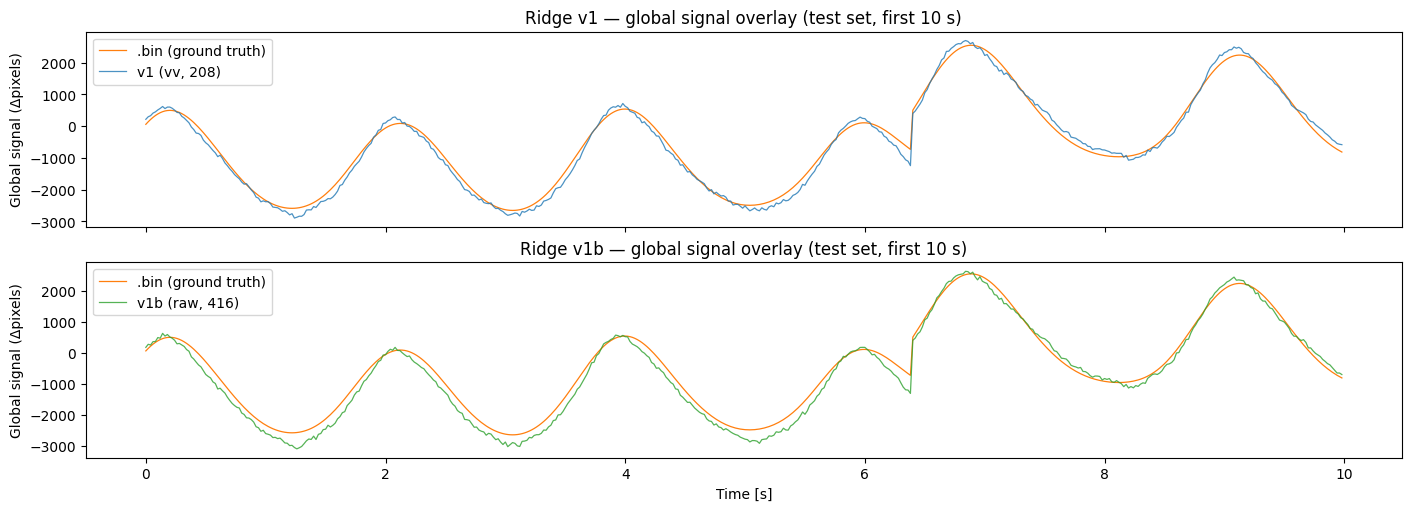

In [8]:
g_true = Y_test.sum(axis=1)
g_v1 = Y_pred_v1.sum(axis=1)
g_v1b = Y_pred_v1b.sum(axis=1)

# Show first 500 frames (~10 s)
fs = 50.0
n_show = 500
t = np.arange(n_show) / fs

fig, axes = plt.subplots(2, 1, figsize=(14, 5), layout="constrained", sharex=True)

axes[0].plot(t, g_true[:n_show], lw=0.9, label=".bin (ground truth)", color="C1")
axes[0].plot(t, g_v1[:n_show], lw=0.9, label="v1 (vv, 208)", color="C0", alpha=0.8)
axes[0].set_ylabel("Global signal (Δpixels)")
axes[0].set_title("Ridge v1 — global signal overlay (test set, first 10 s)")
axes[0].legend()

axes[1].plot(t, g_true[:n_show], lw=0.9, label=".bin (ground truth)", color="C1")
axes[1].plot(t, g_v1b[:n_show], lw=0.9, label="v1b (raw, 416)", color="C2", alpha=0.8)
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Global signal (Δpixels)")
axes[1].set_title("Ridge v1b — global signal overlay (test set, first 10 s)")
axes[1].legend()

plt.show()

## 8. Image comparison — single frame

Side-by-side: .bin ground truth vs v1 prediction vs v1b prediction
at an inspiratory peak (max global signal in the first 200 frames).

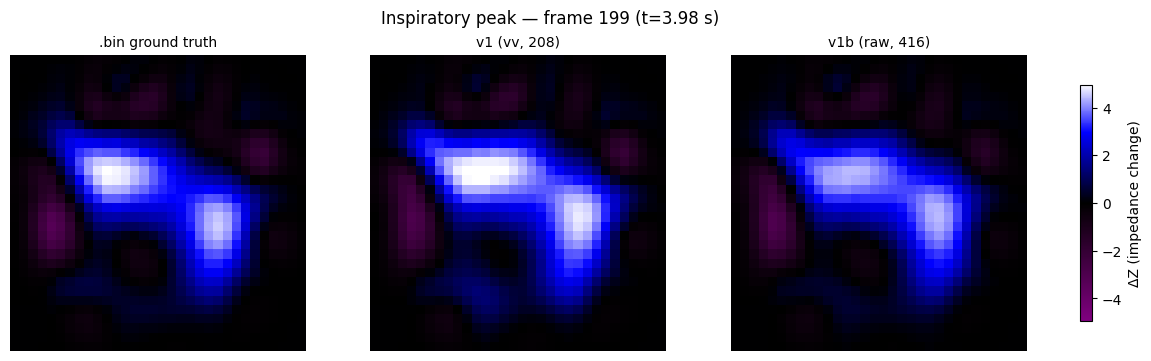

In [9]:
# Find an inspiratory peak in test data
peak_idx = int(np.argmax(g_true[:200]))

img_true = Y_test[peak_idx].reshape(32, 32)
img_v1 = Y_pred_v1[peak_idx].reshape(32, 32)
img_v1b = Y_pred_v1b[peak_idx].reshape(32, 32)

vmax = np.max(np.abs(img_true))

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), layout="constrained")

for ax, img, title in zip(
    axes,
    [img_true, img_v1, img_v1b],
    [".bin ground truth", "v1 (vv, 208)", "v1b (raw, 416)"],
    strict=True,
):
    im = ax.imshow(img, cmap=CMAP_EIT, vmin=-vmax, vmax=vmax, origin="lower")
    ax.set_title(title, fontsize=10)
    ax.axis("off")

fig.colorbar(im, ax=axes, shrink=0.8, label="ΔZ (impedance change)")
fig.suptitle(f"Inspiratory peak — frame {peak_idx} (t={peak_idx/fs:.2f} s)")
plt.show()

## 8b. Reconstruction sequence 4 consecutive frames

Row 1: .bin ground truth, Row 2: v1 prediction, Row 3: v1b prediction.
Same 5 frames, one recording, showing how the model tracks the respiratory cycle.

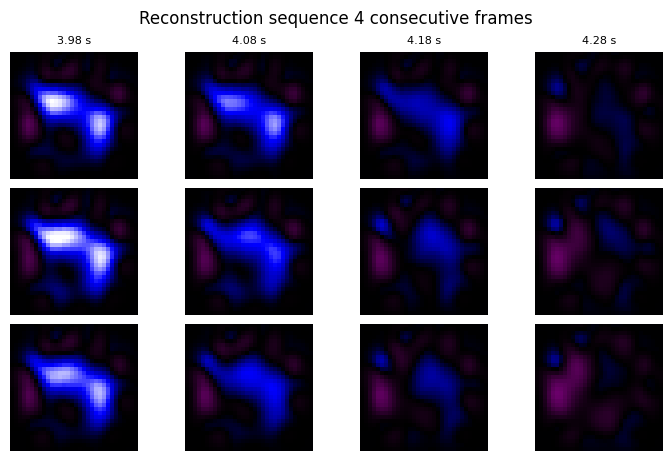

In [20]:
n_seq = 4
stride = 5  

# Start from the inspiratory peak found in section 8
start = peak_idx
frames = list(range(start, start + n_seq * stride, stride))

vmax_seq = np.max(np.abs(Y_test[frames]))

fig, axes = plt.subplots(3, n_seq, figsize=(7, 4.5), layout="constrained")

row_data = [
    (Y_test, ".bin truth"),
    (Y_pred_v1, "v1 (208)"),
    (Y_pred_v1b, "v1b (416)"),
]

for row, (Y_arr, label) in enumerate(row_data):
    for col, idx in enumerate(frames):
        img = Y_arr[idx].reshape(32, 32)
        axes[row, col].imshow(img, cmap=CMAP_EIT, vmin=-vmax_seq, vmax=vmax_seq, origin="lower")
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(label, fontsize=9, rotation=0, labelpad=48, va="center")
        if row == 0:
            axes[row, col].set_title(f"{idx/fs:.2f} s", fontsize=8)

fig.suptitle("Reconstruction sequence 4 consecutive frames", fontsize=12)
plt.show()

## 9. Spatial correlation distribution

Histogram of per-frame Pearson correlation between predicted and
ground-truth images. A tight distribution near 1.0 means the model
consistently reproduces the spatial pattern across all frames.

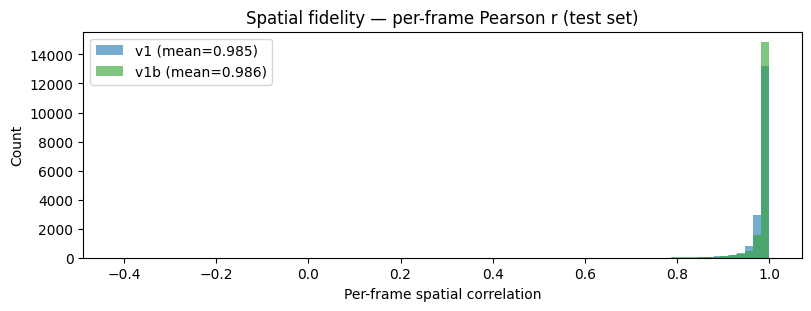

In [11]:
corr_v1 = correlation_per_frame(Y_test, Y_pred_v1)
corr_v1b = correlation_per_frame(Y_test, Y_pred_v1b)

fig, ax = plt.subplots(figsize=(8, 3), layout="constrained")
ax.hist(corr_v1, bins=80, alpha=0.6, label=f"v1 (mean={corr_v1.mean():.3f})", color="C0")
ax.hist(corr_v1b, bins=80, alpha=0.6, label=f"v1b (mean={corr_v1b.mean():.3f})", color="C2")
ax.set_xlabel("Per-frame spatial correlation")
ax.set_ylabel("Count")
ax.set_title("Spatial fidelity — per-frame Pearson r (test set)")
ax.legend()
plt.show()

## 10. MSE over time

MSE per frame plotted over time. That spike indicate frames where the
model struggles more, typically during rapid transitions. I am going to remove that frames and analyze the difference because it's very out of scale.

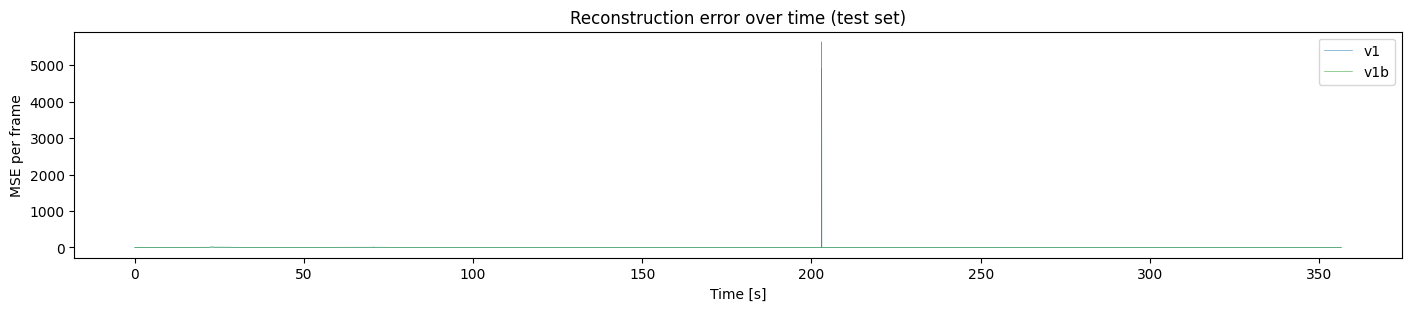

In [12]:
mse_v1 = mse_per_frame(Y_test, Y_pred_v1)
mse_v1b = mse_per_frame(Y_test, Y_pred_v1b)
t_all = np.arange(len(mse_v1)) / fs

fig, ax = plt.subplots(figsize=(14, 3), layout="constrained")
ax.plot(t_all, mse_v1, lw=0.5, label="v1", color="C0", alpha=0.7)
ax.plot(t_all, mse_v1b, lw=0.5, label="v1b", color="C2", alpha=0.7)
ax.set_xlabel("Time [s]")
ax.set_ylabel("MSE per frame")
ax.set_title("Reconstruction error over time (test set)")
ax.legend()
plt.show()

## 11. Error map — mean absolute error per pixel

The next plot shows where the model makes the largest errors spatially.
Expect higher error near the heart region (cardiac artifact)
and at the edges of the lung fields.

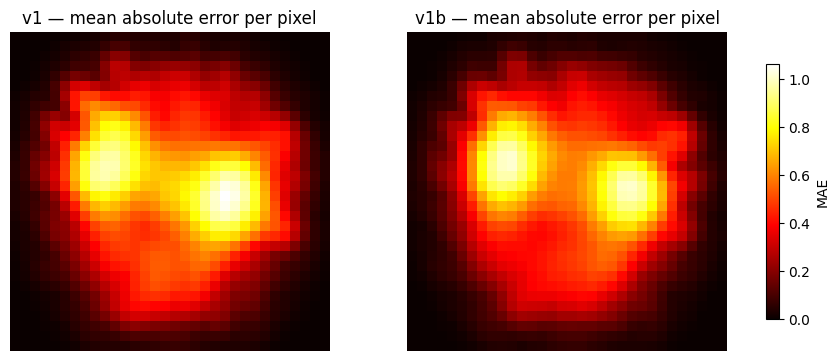

In [13]:
mae_map_v1 = error_map(Y_test, Y_pred_v1)
mae_map_v1b = error_map(Y_test, Y_pred_v1b)

vmax_err = max(mae_map_v1.max(), mae_map_v1b.max())

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), layout="constrained")

im0 = axes[0].imshow(mae_map_v1, cmap="hot", vmin=0, vmax=vmax_err, origin="lower")
axes[0].set_title("v1 — mean absolute error per pixel")
axes[0].axis("off")

im1 = axes[1].imshow(mae_map_v1b, cmap="hot", vmin=0, vmax=vmax_err, origin="lower")
axes[1].set_title("v1b — mean absolute error per pixel")
axes[1].axis("off")

fig.colorbar(im1, ax=axes, shrink=0.8, label="MAE")
plt.show()

## 12. Per-recording metrics breakdown (v1b)

Shows how v1b performs on each recording separately.
This reveals whether certain NIV interfaces or recording
conditions are harder to reconstruct.

In [21]:
mse_v1b_all = mse_per_frame(Y_test, Y_pred_v1b)

print(f"{'Recording':<15s} {'N_test':>7s} {'MSE mean':>10s} {'MSE p99':>10s} {'Glob corr':>10s} {'Spat corr':>10s}")
print("-" * 65)

for label in dict.fromkeys(test_rec_labels):  # preserves order, unique
    mask = test_rec_labels == label
    Yt = Y_test[mask]
    Yp = Y_pred_v1b[mask]
    mse_rec = mse_v1b_all[mask]
    gt = Yt.sum(axis=1)
    gp = Yp.sum(axis=1)
    gc = float(np.corrcoef(gt, gp)[0, 1]) if np.std(gt) > 0 else 0
    sc = float(correlation_per_frame(Yt, Yp).mean())
    print(
        f"{label:<15s} {mask.sum():>7d} "
        f"{mse_rec.mean():>10.3f} {np.percentile(mse_rec, 99):>10.2f} "
        f"{gc:>10.4f} {sc:>10.4f}"
    )

Recording        N_test   MSE mean    MSE p99  Glob corr  Spat corr
-----------------------------------------------------------------
p01_rec02           320      0.308       1.03     0.9943     0.9607
p01_rec03          1150      2.171      11.04     0.9497     0.9567
p01_rec04          2250      0.846       6.35     0.9591     0.9840
p01_rec05          2300      0.041       0.18     0.9945     0.9954
p01_rec07          2010      0.050       0.19     0.9929     0.9765
p01_rec09          1440      0.198       1.33     0.9889     0.9917
p01_rec11          1650      3.424       2.92     0.6850     0.9883
p01_rec12          1320      0.311       1.47     0.9780     0.9842
p01_rec13          2960      0.212       1.33     0.9882     0.9933
patient02          2430      0.115       0.31     0.9624     0.9907


## 13. Outlier filtering and clean metrics

From section 10 I notice that spike around 200 sec. It end up that rec11 had 1 glitch frame (MSE=4800) that destroys global correlation.

Filter: remove frames with MSE > 50 (try to catch glitches).

In [15]:
MSE_THRESHOLD = 50
good_mask = mse_v1b_all < MSE_THRESHOLD
n_removed = (~good_mask).sum()

print(f'Outlier filter: MSE > {MSE_THRESHOLD}')
print(f'  Removed: {n_removed} frames ({n_removed/len(good_mask)*100:.2f}%)')
print(f'  Kept:    {good_mask.sum()} / {len(good_mask)}')

# Clean metrics — v1b
m_clean = summary_metrics(Y_test[good_mask], Y_pred_v1b[good_mask])

print(f"\n{'Metric':<25s} {'Raw':>10s} {'Clean':>10s}")
print("-" * 47)
for key in m_v1b:
    print(f"{key:<25s} {m_v1b[key]:>10.4f} {m_clean[key]:>10.4f}")

# Clean per-recording
print(f"\n{'Recording':<15s} {'MSE mean':>10s} {'Glob corr':>10s} {'Spat corr':>10s}")
print("-" * 50)
mse_clean = mse_per_frame(Y_test[good_mask], Y_pred_v1b[good_mask])
labels_clean = test_rec_labels[good_mask]
for label in dict.fromkeys(test_rec_labels):
    mask = labels_clean == label
    if not mask.any():
        continue
    Yt = Y_test[good_mask][mask]
    Yp = Y_pred_v1b[good_mask][mask]
    gt, gp = Yt.sum(axis=1), Yp.sum(axis=1)
    gc = float(np.corrcoef(gt, gp)[0, 1])
    sc = float(correlation_per_frame(Yt, Yp).mean())
    print(f"{label:<15s} {mse_clean[mask].mean():>10.3f} {gc:>10.4f} {sc:>10.4f}")

Outlier filter: MSE > 50
  Removed: 2 frames (0.01%)
  Kept:    17828 / 17830

Metric                           Raw      Clean
-----------------------------------------------
r2                            0.9483     0.9699
rmse                          0.8186     0.6245
mse_mean                      0.6701     0.3901
mse_std                      36.7672     1.1433
corr_spatial_mean             0.9859     0.9860
corr_spatial_std              0.0320     0.0300
corr_global                   0.9432     0.9838

Recording         MSE mean  Glob corr  Spat corr
--------------------------------------------------
p01_rec02            0.308     0.9943     0.9607
p01_rec03            2.171     0.9497     0.9567
p01_rec04            0.846     0.9591     0.9840
p01_rec05            0.041     0.9945     0.9954
p01_rec07            0.050     0.9929     0.9765
p01_rec09            0.198     0.9889     0.9917
p01_rec11            0.398     0.9905     0.9894
p01_rec12            0.311     0.9780     0.9

## Summary

### v1 vs v1b:

With per-model optimal alpha (v1 and v1b: alpha=0.1), global
metrics are nearly identical. However v1b so far shows advantages in:
- **Higher global correlation** (0.944 vs 0.940)
- **Robustness at recording boundaries**: v1 shows MSE spikes when
  switching between recordings (probably different hardware calibration constants),
  v1b does not, I think because raw features (`trans_A` and `trans_B`) bypass Adler's formula.

### Results (10 recordings, ~89k frames, 2 patients)

| Model | Input | Features | Alpha | R² test | Spatial corr | Global corr |
|-------|-------|----------|-------|---------|-------------|-------------|
| v1 | `vv` (Adler calibrated) | 208 | 10 | 0.949 | 0.985 | 0.940 |
| **v1b** | `[trans_A, trans_B]` (raw) | **416** | 1 | **0.949** | **0.986** | **0.944** |


### Notes
- **rec11** has 1 outlier frame (MSE=4700) that inflates MSE std — likely a recording glitch

### Limitations
- Only 2 patients — cross-patient generalisation not yet proven
- 80/20 sequential split within each recording (not LOPO-CV)
- Next step: more patients for real LOPO-CV validation